# Scalable EO workflow using openEO: A Case Study on Flood Change Detection with Sentinel-1 Data

## Introduction

The Copernicus Data Space Ecosystem facilitates cloud processing of Earth Observation (EO) data through its streamlined data access APIs, including the openEO API. The openEO represents an innovative community standard for accessing, processing, and analyzing diverse Earth observation data.

### Why openEO?

Traditionally, EO data processing has been complex and time-consuming, requiring users to discover, download and pre-process large datasets locally. The lack of standardization and interoperability among EO data providers, combined with limited scalable and cost-effective computing resources, has further complicated the process. As a result, researchers often spend considerable time and resources on data preparation and processing, detracting from their focus on data analysis and interpretation.

**Before openEO**
 <div style="flex: 1;align-items: right; max-height: 500px;">
    <img src="./fig/traditional.png" style="height: 400px; width: auto;padding-left: 20px;">
  </div>

Consequently, **cloud-based processing platforms** have emerged as a popular and standard solution.

<div style="display: flex; align-items: stretch;">
  <div style="flex: 3; padding-left: 5px; text-align: left;max-width: 600px;">
    <h3>What is openEO?</h3>

openEO is an **open-source** API for the cloud-based processing of EO data. 

It standardises this traditional EO data processing workflow, providing a **unified** solution to streamline **access, processing, and analysis** of diverse EO datasets using familiar programming languages like Python, etc. Users can effortlessly **share** code, workflows, and data processing algorithms across different platforms and tools, fostering easy **accessibility, scalability, and reproducibility**.

<p><h4>Added Value with openEO</h4>


* **Unified** and **straightforward** access & processing to multiple Earth observation datasets
* **Scalable** processing
* A **standardized** system that makes different platforms​ **Interoperable**
* **Independence** from underlying technologies and software libraries​
* **FAIR** and **open-science** principles

Hence, by adopting openEO, developers, researchers, and data scientists can efficiently use distributed computing environments and cloud-based resources to tackle complex geospatial challenges. 
  </div>
  <div style="flex: 1;align-items: right; max-height: 500px;">
    <img src="./fig/openeo.png" alt="openEO" style="height: 100%; width: auto;padding-left: 100px;">
  </div>
</div>




## Where to start?

For beginners, the openEO API's ["Getting Started"](https://documentation.dataspace.copernicus.eu/APIs/openEO/Python_Client/Python.html) documentation is a good starting point, providing a comprehensive guide and examples to help you get started. 

Advanced users will also find it valuable to explore openEO's capabilities, including its adherence to FAIR principles, open science practices, handling large-scale processing and many more. 

### Installation

The openEO Python client library is available from PyPI and can be easily installed with a tool like **pip**.

If not, install them using:

```bash
pip install openeo
```

Similarly, for R:

```r
install.packages("openeo")
library(openeo)
```

### Connect to openEO backend


There are multiple openEO backends available, each with its own unique features and capabilities. You can find a list of these backends on the [openEO Hub](https://openeo.org/hub/), which provides detailed information about each backend, including supported data collections, processing capabilities, and access methods.

Let's set up a connection to an openEO backend using its connection URL. In this notebook, we'll use the Copernicus Data Space Ecosystem, a cloud platform supported by the European Commission, ESA, and Copernicus, therefore the connection url is: https://openeo.dataspace.copernicus.eu/

![](./fig/backends.png)


In [1]:
import openeo

connection = openeo.connect("https://openeo.dataspace.copernicus.eu/").authenticate_oidc()
connection.capabilities()

Authenticated using refresh token.


### Data discovery and access

The Earth observation data is organised in so-called collections. You can programmatically list the collections available on a backend and their metadata using methods on the `connection` object. Furthermore, to visualise available collections and metadata in a user-friendly manner, you can also visit the [openEO hub](https://hub.openeo.org/) or explore [backend-specific openEO web editor](https://openeo.dataspace.copernicus.eu/).  

Get specific metadata about the collections, such as spatial and temporal coverage, available bands, and data formats.

In [2]:
connection.describe_collection("SENTINEL1_GRD")

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['HH', 'HV', 'VH', 'VV']},
  't': {'extent': [None, None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [0, 0],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'version': '1.3'},
    'name': 'AUTO 42001 (Universal Transverse Mercator)',
    'type': 'GeodeticCRS'},
   'step': 10,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [0, 0],
   'reference_system': {'$schema': 'https://proj.org/schemas/v0.2/projjson.schema.json',
    'area': 'World',
    'bbox': {'east_longitude': 180,
     'north_latitude': 90,
     'south_latitude': -90,
     'west_longitude': -180},
    'coordinate_system': {'axis': [{'abbreviation': 'Lat',
       'direction': 'north',
       'name': 'Geodetic latitude',
       'unit': 'degree'},
      {'abbreviation': 'Lon',
       'direction': 'east',
       'name': 'Geodetic longitude',
       'unit': 'degree'}],
     'subtype': 'ellipsoidal'},
    'datum': {'ellipsoid': {'inverse_flattening': 298.257223563,
      'name': 'WGS 84',
      'semi_major_axis': 6378137},
     'name': 'World Geodetic System 1984',
     'type': 'GeodeticReferenceFrame'},
    'id': {'authority': 'OGC', 'code': 'Auto42001', 'version': '1.3'},
    'name': 'AUTO 42001 (Universal Transverse Mercator)',
    'type': 'GeodeticCRS'},
   'step': 10,
   'type': 'spatial'}},
 'description': 'The Sentinel-1 mission provides data from a dual-polarization C-band Synthetic Aperture Radar (SAR) instrument. This collection includes the S1 Ground Range Detected (GRD) scenes, processed to a calibrated, ortho-corrected product. This collection is compatible with "sar_backscatter" and "ard_normalized_radar_backscatter" processes.',
 'extent': {'spatial': {'bbox': [[0, 0, 0, 0]]},
  'temporal': {'interval': [[None, None]]}},
 'id': 'SENTINEL1_GRD',
 'keywords': ['raster',
  'systematic',
  'satellite imagery',
  'SAR',
  'radar',
  'backscattering',
  'polarization',
  'Copernicus',
  'maritime monitoring',
  'land monitoring',
  'disaster response',
  'open data'],
 'license': 'proprietary',
 'links': [{'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/SENTINEL1_GRD',
   'rel': 'self'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/SENTINEL1_GRD/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'}],
 'mission': 'Sentinel-1',
 'name': 'SENTINEL1_GRD',
 'product_id': 'SENTINEL1_GRD',
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json',
  'https://stac-extensions.github.io/eo/v1.1.0/schema.json'],
 'stac_version': '0.9.0',
 'summaries': {'bands': [{'name': 'HH'},
   {'name': 'HV'},
   {'name': 'VH'},
   {'name': 'VV'}],
  'constellation': ['sentinel-1'],
  'eo:bands': [{'name': 'HH', 'type': 'float', 'unit': '1'},
   {'name': 'HV', 'type': 'float', 'unit': '1'},
   {'name': 'VH', 'type': 'float', 'unit': '1'},
   {'name': 'VV', 'type': 'float', 'unit': '1'}],
  'instrument': ['c-sar'],
  'platform': ['sentinel-1a', 'sentin

### A Case Study on Flood Change Detection with Sentinel-1 Data

openEO can be used for a wide range of Earth Observation (EO) applications, from simple to advanced workflows. In this notebook, we will demonstrate a simple workflow to use openEO for **flood change detection using Sentinel-1 data**.

The workflow compares radar imagery before and after a flood event to identify newly inundated areas, showcasing a simple yet powerful analysis pattern that can be adapted to many environmental monitoring use cases.

To summarize the steps involved compared to the traditional workflow, the following steps are included for this specific use case:

<div style="display: flex; align-items: stretch;">
  <div style="flex: 3; padding-right: 20px; text-align: left;max-width: 600px;">
<p>
    
1. **Load Sentinel 1 GRD** from CDSE backend for **area and time of interest**
2. Apply openEO's built-in **processes** in the workflow
3. Execute the job in **CDSE cloud environment**</p>
  </div>
  <div style="flex: 1;align-items: right; max-height: 300px;">
    <img src="./fig/traditional.png" style="height: 100%; width: auto;padding-left: 20px;">
  </div>
</div>

[Storm Boris](http://nl.wikipedia.org/wiki/Boris_(cycloon)) brought severe flooding to Central Europe in September 2024. It caused significant damage in the Czech Republic, Poland, and Austria. In this case study, we will explore for a specific location in the Czech Republic. 

In [3]:
spatial_extent = {"west": 17.05,"south": 50.07,"east": 17.31,"north": 50.25}

# plot spatial extent
import folium
map = folium.Map(
    location=[(spatial_extent["south"] + spatial_extent["north"]) / 2, (spatial_extent["west"] + spatial_extent["east"]) / 2], 
    zoom_start=13
    )
folium.Rectangle(
    bounds=[[spatial_extent["south"], spatial_extent["west"]], [spatial_extent["north"], spatial_extent["east"]]],
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.2
).add_to(map)
map


Next, let us load the Sentinel-1 GRD data from the CDSE backend for our area of interest and time range, and load the relevant bands for flood detection (VV and VH polarizations).

Next, using the inbuilt processes in openEO such as `sar_backscatter`, we can easily compute the backscatter coefficients needed for flood detection without having to write complex code for data handling and processing.

In [4]:
before_cube = connection.load_collection(        
                            "SENTINEL1_GRD",        
                            spatial_extent=spatial_extent,        
                            temporal_extent=["2024-08-25", "2024-09-09"],        
                            bands=["VV"],        
                            properties={"sat:orbit_state": lambda x: x == "descending"})    
# applying radiometric corrections
before_cube = before_cube.sar_backscatter(coefficient="sigma0-ellipsoid")

Using the `median_time` process of openEO, we can compute the median backscatter value for each pixel across the time series, which helps to reduce noise and improve the accuracy of flood detection.

In [5]:
# temporal reduction to get a single image for the before period
before_median = before_cube.median_time()    

Similarly, the median backscatter values for post-flood is calculated as sh

In [6]:
after_cube = connection.load_collection(        
                            "SENTINEL1_GRD",        
                            spatial_extent=spatial_extent,        
                            temporal_extent=["2024-09-11", "2024-09-25"],        
                            bands=["VV"],        
                            properties={"sat:orbit_state": lambda x: x == "descending"}) 
after_cube = after_cube.sar_backscatter(coefficient="sigma0-ellipsoid")    
after_median = after_cube.median_time()    


To identify water bodies in the radar imagery, we can apply a backscatter threshold to the computed median backscatter logarithmic values. 

```
0  dB -> Strong reflector (metal, corner reflector)
     ║
-5  dB -> Urban areas, concrete
     ║
-10 dB -> Forest, rough terrain
     ║
-15 dB -> WATER THRESHOLD!
     ║
-20 dB -> Calm water (lakes, smooth areas)
     ║
-25 dB -> Very smooth water
```

The backscatter coefficient (in dB) for water bodies is typically lower than that of land surfaces due to the smoothness of water, which results in less radar signal being reflected back to the sensor.

In [7]:
threshold = -15   
before_water = before_median.apply(
                        lambda x: openeo.processes.if_(
                            10 * openeo.processes.log(x, base=10) < threshold, 
                            1,0)
                            )
before_water_result = before_water.save_result(format="GTiff", options={"filename_prefix": "before_water"})

after_water = after_median.apply(
                        lambda x: openeo.processes.if_(
                            10 * openeo.processes.log(x, base=10) < threshold, 
                            1,0)
                            )
after_water_result = after_water.save_result(format="GTiff", options={"filename_prefix": "after_water"})

Furthermore, to efficiently compare the pre and post-flood outputs, let us save intermediate results in a single openEO workflow. This avoids re-running the same processes multiple times. For more information on saving intermediate results in the workflow, please refer to the [openEO documentation](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.multiresult.MultiResult).

Next, we can simply compare the binary water masks for pre and post-flood periods to identify newly flooded areas. This can be done using a simple subtraction operation, where pixels that were non-water before but are water after the flood will be highlighted as newly inundated areas.

In [8]:
flood_change = after_water - before_water    
flood_change_result = flood_change.save_result(format="GTiff", options={"filename_prefix": "change_detection"})
flood_change_result

Please note that while this looks like an actual calculation, real data processing still needs to be done. At this point, the **flood_change_result** object is just an abstract representation of our algorithm under construction. The mathematical operators we used here are syntactic sugar for compactly expressing this part of the algorithm.

In [9]:
saving_multiple_result = openeo.MultiResult(
        [flood_change_result, before_water_result, after_water_result]
    )

Finally, to trigger an actual execution (on the backend), we have to explicitly send the above representation to the backend. We can do this either synchronously(simple download) or using the batch-job-based method. 

Most of the simple, basic openEO usage examples show synchronous downloading of results. Synchronous downloads are handy for quick experimentation on small data cubes.

This only works properly if the processing doesn’t take too long and is focused on a smaller area of interest. However, you have to use batch jobs for the heavier work (larger regions of interest, larger time series, more intensive processing).

For more information on using batch-job in openEO, visit [here](https://open-eo.github.io/openeo-python-client/batch_jobs.html).

In [10]:
openeo_job = saving_multiple_result.create_job(title="Flood Change Detection", description="Detecting flood changes using Sentinel-1 data")
openeo_job.start_and_wait()

0:00:00 Job 'j-260409144508448984031b1951605ff3': send 'start'
0:00:16 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:00:21 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:00:28 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:00:36 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:00:46 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:00:58 Job 'j-260409144508448984031b1951605ff3': created (progress 0%)
0:01:14 Job 'j-260409144508448984031b1951605ff3': running (progress N/A)
0:01:33 Job 'j-260409144508448984031b1951605ff3': running (progress N/A)
0:01:58 Job 'j-260409144508448984031b1951605ff3': running (progress N/A)
0:02:28 Job 'j-260409144508448984031b1951605ff3': running (progress N/A)
0:03:05 Job 'j-260409144508448984031b1951605ff3': running (progress N/A)
0:03:53 Job 'j-260409144508448984031b1951605ff3': finished (progress 100%)


<BatchJob job_id='j-260409144508448984031b1951605ff3'>

#### What Happens When You Submit
1. Your Python code → Process graph (JSON) is sent to backend
2. Job queued
3. Backend optimizes execution plan
4. Executes on distributed infrastructure
5. Results stored temporarily
6. You download results

In [14]:
results = openeo_job.get_results()
results.download_files("my_flood_change_results/")

[WindowsPath('my_flood_change_results/after_water.tif'),
 WindowsPath('my_flood_change_results/before_water.tif'),
 WindowsPath('my_flood_change_results/change_detection.tif'),
 WindowsPath('my_flood_change_results/job-results.json')]

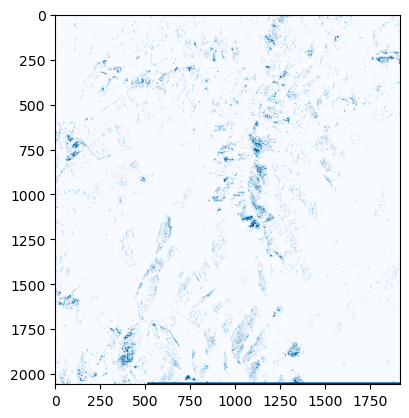

In [21]:
import rasterio
import matplotlib.pyplot as plt


with rasterio.open("my_flood_change_results/change_detection.tif") as src:
    flood_change_data = src.read(1)  # Read the first band
plt.imshow(flood_change_data.astype(bool), cmap="Blues", vmin=0, vmax=1)

### Conclusion

Working with openEO allows you to efficiently process and analyze Earth observation data in the cloud, without the need for complex local setups. By leveraging the power of cloud computing and the flexibility of the openEO API, you can focus on your analysis and insights rather than data handling and processing logistics.

In the above workflow, we have generated three key outputs:
1. **Before Water Map** (binary mask of water bodies before the flood)
2. **After Water Map** (binary mask of water bodies after the flood)
3. **Flood Change Map** (binary mask of newly flooded areas)

These generated maps can be used for further analysis, visualization, or integration into GIS software. They could serve as important inputs for emergency response teams, urban planners, and environmental scientists to assess flood impacts and plan mitigation strategies within few hours after the event, without needing to download and process large datasets locally.



### Resources
- **openEO Portal:** https://openeo.org
- **Python Client Docs:** https://open-eo.github.io/openeo-python-client/
- **Community examples:** https://github.com/Open-EO/openeo-community-examples
- **Copernicus Data Space Documentation:** https://dataspace.copernicus.eu